Nodes per layer:
  E: 11 nodes, mean influence 0.1784
  0: 833 nodes, mean influence 0.7207
  1: 509 nodes, mean influence 0.8071
  2: 357 nodes, mean influence 0.7826
  3: 383 nodes, mean influence 0.7947
  4: 551 nodes, mean influence 0.822
  5: 531 nodes, mean influence 0.8563
  6: 508 nodes, mean influence 0.8479
  7: 327 nodes, mean influence 0.8452
  8: 249 nodes, mean influence 0.8316
  9: 287 nodes, mean influence 0.8472
  10: 278 nodes, mean influence 0.8756
  11: 51 nodes, mean influence 0.7879
  12: 43 nodes, mean influence 0.76
  13: 55 nodes, mean influence 0.8048
  14: 51 nodes, mean influence 0.7757
  15: 44 nodes, mean influence 0.7572
  16: 37 nodes, mean influence 0.718
  17: 41 nodes, mean influence 0.7352
  18: 40 nodes, mean influence 0.7224
  19: 25 nodes, mean influence 0.7039
  20: 32 nodes, mean influence 0.6788
  21: 29 nodes, mean influence 0.7196
  22: 18 nodes, mean influence 0.636
  23: 27 nodes, mean influence 0.6068
  24: 24 nodes, mean influence 0.5956


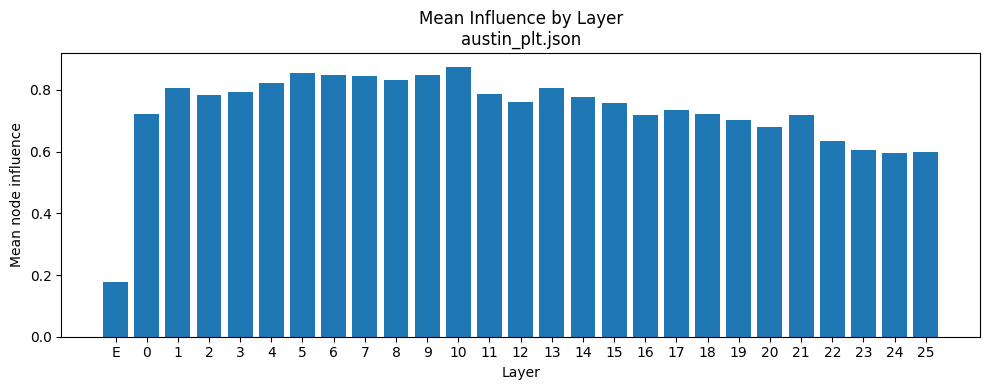

{'0': 0.7206691480985209,
 '1': 0.8070795473391977,
 '2': 0.7825524525649074,
 '3': 0.7946935101526524,
 '4': 0.8220003495523588,
 '5': 0.8562901596452781,
 '6': 0.8479303788599066,
 '7': 0.8452386786813765,
 '8': 0.8316483419822401,
 '9': 0.8472122112840725,
 '10': 0.8756172156376805,
 '11': 0.7878806795559677,
 '12': 0.7599536492380985,
 '13': 0.8047857831824909,
 '14': 0.7756590673736498,
 '15': 0.7571992704814131,
 '16': 0.7179797613942945,
 '17': 0.7351786726858558,
 '18': 0.7223523303866386,
 '19': 0.7039155161380768,
 '20': 0.6788460677489638,
 '21': 0.7195629241137669,
 '22': 0.6359769056240717,
 '23': 0.6068333519829644,
 '24': 0.5956492361923059,
 '25': 0.597991495363174,
 'E': 0.17840622941201384}

In [2]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def plot_mean_influence_by_layer(graph_json_path: str):
    p = Path(graph_json_path)
    with p.open("r", encoding="utf-8") as f:
        data = json.load(f)

    nodes = data.get("nodes", [])
    layer_to_vals = defaultdict(list)
    layer_counts = defaultdict(int)

    for n in nodes:
        layer = str(n.get("layer", "unknown"))
        layer_counts[layer] += 1
        influence = n.get("influence", None)
        if isinstance(influence, (int, float)) and np.isfinite(influence):
            layer_to_vals[layer].append(float(influence))

    # keep layers with at least 1 valid influence
    layer_mean = {
        layer: float(np.mean(vals))
        for layer, vals in layer_to_vals.items()
        if len(vals) > 0
    }

    # sort: E first, then numeric layers, then anything else
    def layer_key(x: str):
        if x == "E":
            return (0, -1)
        if x.isdigit():
            return (1, int(x))
        return (2, x)

    # print counts per layer (include layers without valid influence)
    all_layers = sorted(set(list(layer_counts.keys()) | set(layer_mean.keys())), key=layer_key)
    print("Nodes per layer:")
    for l in all_layers:
        cnt = layer_counts.get(l, 0)
        if l in layer_mean:
            print(f"  {l}: {cnt} nodes, mean influence {layer_mean[l]:.4g}")
        else:
            print(f"  {l}: {cnt} nodes, no valid influence")

    layers = sorted(layer_mean.keys(), key=layer_key)
    means = [layer_mean[l] for l in layers]

    plt.figure(figsize=(10, 4))
    plt.bar(layers, means)
    plt.xlabel("Layer")
    plt.ylabel("Mean node influence")
    plt.title(f"Mean Influence by Layer\n{p.name}")
    plt.tight_layout()
    plt.show()
    
    return layer_mean


# Example:
plot_mean_influence_by_layer("temp_graph_files/austin_plt.json")

In [16]:
from circuit_tracer.subgraph.utils import get_data_from_json, _build_index_sets
from circuit_tracer.graph import compute_node_influence, compute_node_relevance
import torch
adj_matrix, node_ids, attr, metadata = get_data_from_json("temp_graph_files/austin_plt.json")

idx = _build_index_sets(node_ids, attr)
n = adj_matrix.shape[0]
logits_seed = torch.zeros(n, device=adj_matrix.device)
for i in idx["logit"]:
    nid = node_ids[i]
    logits_seed[i] = float(attr.get(nid, {}).get("token_prob", 0.0))
influence = compute_node_influence(adj_matrix, logits_seed)

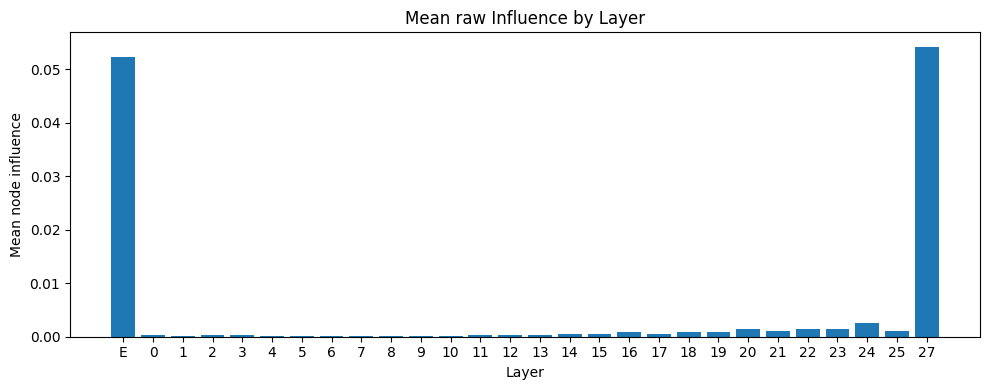

In [17]:
from collections import defaultdict

mean_inf_by_layer = defaultdict(list)
for i, inf in enumerate(influence):
    layer = attr.get(node_ids[i], {}).get("layer", "unknown")
    try:
        val = float(inf)
    except Exception:
        continue
    if np.isfinite(val):
        mean_inf_by_layer[str(layer)].append(val)

layer_mean = {layer: float(np.mean(vals)) for layer, vals in mean_inf_by_layer.items() if len(vals) > 0}

def layer_key(x: str):
    if x == "E":
        return (0, -1)
    if x.isdigit():
        return (1, int(x))
    return (2, x)

layers = sorted(layer_mean.keys(), key=layer_key)
means = [layer_mean[l] for l in layers]

plt.figure(figsize=(10, 4))
plt.bar(layers, means)
plt.xlabel("Layer")
plt.ylabel("Mean node influence")
plt.title("Mean raw Influence by Layer")
plt.tight_layout()
plt.show()


In [18]:
print(means)

[0.05219008502635089, 0.0004026351485580148, 0.0002227898450962964, 0.00028666587810963066, 0.00024408796864778154, 0.00022289976935270175, 0.00015271380480540883, 0.0001686459789011929, 0.0001929179247155777, 0.00019627036202741493, 0.0001722329984928517, 0.00013892804060737258, 0.0003302108191693311, 0.0003795868891080148, 0.0003544836798524061, 0.00047966764495689787, 0.00048585950034149306, 0.0008079745531250484, 0.0004865350965701509, 0.0008126214141157106, 0.0009161317709367723, 0.0014710239383930457, 0.0011599440693881378, 0.0014616006547940844, 0.0015271886850651182, 0.002552390446605083, 0.0010666150523203186, 0.054160252368698515]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

prune_eval_results = pd.read_csv("eval_shap_prune/clt-hp/summary.csv")
prune_eval_results.head()

,source_set,graph_file,graph_stem,shap_json,shap_row_index,masker_keep_prefix,normalize_method,node_threshold,edge_threshold,num_nodes,num_edges,combined_retention,combined_completeness,combined_scores_method,combined_scores_normalization,combined_scores_alpha,prune_graph_path
0,clt-hp,clt-hp-p01-fact-the-capital-of-20260501-161357...,clt-hp-p01-fact-the-capital-of-20260501-161357...,demos/shap_values.json,1,3,softmax,0.0,0.95,1,0,1.0,1.0,geometric,min_max,0.5,demos/eval_shap_prune/clt-hp/softmax/node_0.0/...
1,clt-hp,clt-hp-p01-fact-the-capital-of-20260501-161357...,clt-hp-p01-fact-the-capital-of-20260501-161357...,demos/shap_values.json,1,3,softmax,0.1,0.95,1,0,1.0,1.0,geometric,min_max,0.5,demos/eval_shap_prune/clt-hp/softmax/node_0.1/...
2,clt-hp,clt-hp-p01-fact-the-capital-of-20260501-161357...,clt-hp-p01-fact-the-capital-of-20260501-161357...,demos/shap_values.json,1,3,softmax,0.2,0.95,1,0,1.0,1.0,geometric,min_max,0.5,demos/eval_shap_prune/clt-hp/softmax/node_0.2/...
3,clt-hp,clt-hp-p01-fact-the-capital-of-20260501-161357...,clt-hp-p01-fact-the-capital-of-20260501-161357...,demos/shap_values.json,1,3,softmax,0.3,0.95,1,0,1.0,1.0,geometric,min_max,0.5,demos/eval_shap_prune/clt-hp/softmax/node_0.3/...
4,clt-hp,clt-hp-p01-fact-the-capital-of-20260501-161357...,clt-hp-p01-fact-the-capital-of-20260501-161357...,demos/shap_values.json,1,3,softmax,0.4,0.95,2,1,1.0,1.0,geometric,min_max,0.5,demos/eval_shap_prune/clt-hp/softmax/node_0.4/...


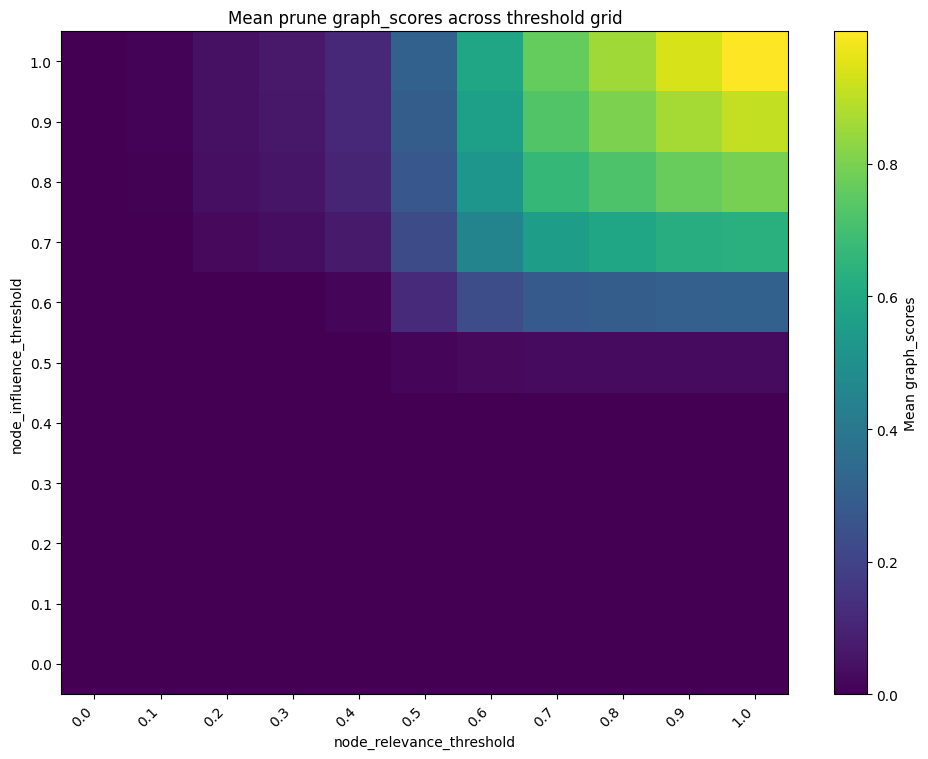

Loaded 5492 files
Unique node_inf thresholds: [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]
Unique node_rel thresholds: [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]


node_rel,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
node_inf,,,,,,,,,,,
0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.3,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.4,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.5,0.0,0.000000,0.000000,0.000000,0.000000,0.012114,0.023947,0.030654,0.031170,0.031170,0.031170
0.6,0.0,0.000000,0.000000,0.000000,0.016722,0.121300,0.236405,0.282824,0.293449,0.305655,0.310345
0.7,0.0,0.003176,0.023672,0.035407,0.074164,0.233800,0.450604,0.556257,0.592481,0.622433,0.636690
0.8,0.0,0.007464,0.040883,0.057998,0.102004,0.272038,0.524577,0.664630,0.721634,0.767368,0.795389


In [5]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


def plot_prune_graph_score_heatmap(
    root_dir: str = "eval_shap_prune/clt-hp",
    file_glob: str = "*_prune_graph.pt",
):
    """
    Read prune-graph .pt files under folders named:
      node_inf_{node_influence_threshold}_rel_{node_relevance_threshold}
    and plot mean graph_scores as a heatmap.
    """
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"Directory not found: {root}")

    threshold_dir_pattern = re.compile(
        r"^node_inf_(?P<node_inf>[-+]?\d*\.?\d+)_rel_(?P<node_rel>[-+]?\d*\.?\d+)$"
    )

    records = []
    for p in root.rglob(file_glob):
        parent_name = p.parent.name
        m = threshold_dir_pattern.match(parent_name)
        if not m:
            continue

        node_inf = float(m.group("node_inf"))
        node_rel = float(m.group("node_rel"))

        payload = torch.load(p, map_location="cpu")
        if isinstance(payload, dict):
            score = payload.get("graph_scores", None)
        else:
            score = getattr(payload, "graph_scores", None)

        if score is None:
            continue
        score = float(score)
        if not np.isfinite(score):
            continue

        records.append(
            {
                "node_inf": node_inf,
                "node_rel": node_rel,
                "graph_score": score,
                "file": str(p),
            }
        )

    if not records:
        raise RuntimeError(
            f"No matching prune graph files with graph_scores found under: {root}"
        )

    df = pd.DataFrame(records)

    heatmap_df = (
        df.groupby(["node_inf", "node_rel"], as_index=False)["graph_score"]
        .mean()
        .pivot(index="node_inf", columns="node_rel", values="graph_score")
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    fig_w = max(8, 0.9 * len(heatmap_df.columns))
    fig_h = max(6, 0.7 * len(heatmap_df.index))
    plt.figure(figsize=(fig_w, fig_h))

    values = heatmap_df.values
    im = plt.imshow(values, aspect="auto", origin="lower", cmap="viridis")
    plt.colorbar(im, label="Mean graph_scores")

    plt.xticks(
        ticks=np.arange(len(heatmap_df.columns)),
        labels=[f"{x:.1f}" for x in heatmap_df.columns],
        rotation=45,
        ha="right",
    )
    plt.yticks(
        ticks=np.arange(len(heatmap_df.index)),
        labels=[f"{x:.1f}" for x in heatmap_df.index],
    )

    plt.xlabel("node_relevance_threshold")
    plt.ylabel("node_influence_threshold")
    plt.title("Mean prune graph_scores across threshold grid")
    plt.tight_layout()
    plt.show()

    print(f"Loaded {len(df)} files")
    print(f"Unique node_inf thresholds: {sorted(df['node_inf'].unique())}")
    print(f"Unique node_rel thresholds: {sorted(df['node_rel'].unique())}")

    return df, heatmap_df


# Run
df_scores, heatmap_scores = plot_prune_graph_score_heatmap("eval_shap_prune/clt-hp")
heatmap_scores

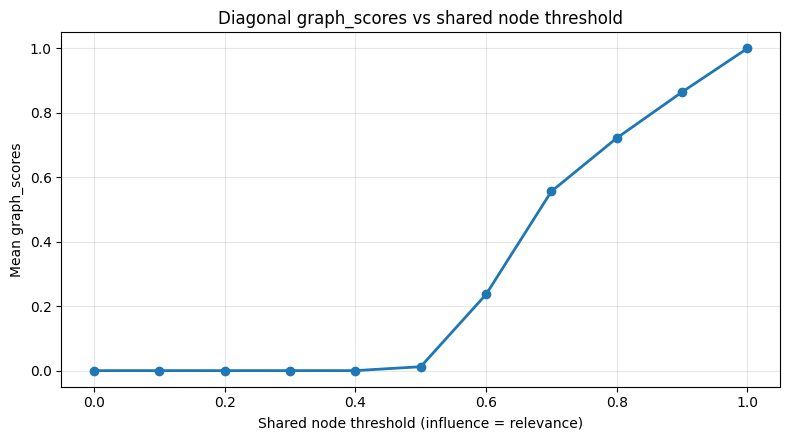

,threshold,graph_score
0,0.0,0.000000
1,0.1,0.000000
2,0.2,0.000000
3,0.3,0.000000
4,0.4,0.000000
5,0.5,0.012114
6,0.6,0.236405
7,0.7,0.556257
8,0.8,0.721634
9,0.9,0.864571


In [6]:
import numpy as np
import matplotlib.pyplot as plt


def plot_diagonal_graph_scores(df_scores, tol: float = 1e-9):
    """
    Plot mean graph_scores on the diagonal where:
      node_influence_threshold == node_relevance_threshold
    """
    diag = df_scores[np.isclose(df_scores["node_inf"], df_scores["node_rel"], atol=tol)].copy()
    if diag.empty:
        raise RuntimeError("No diagonal points found (node_inf ~= node_rel).")

    diag["threshold"] = diag["node_inf"]
    diag_mean = (
        diag.groupby("threshold", as_index=False)["graph_score"]
        .mean()
        .sort_values("threshold")
    )

    plt.figure(figsize=(8, 4.5))
    plt.plot(
        diag_mean["threshold"],
        diag_mean["graph_score"],
        marker="o",
        linewidth=2,
    )
    plt.xlabel("Shared node threshold (influence = relevance)")
    plt.ylabel("Mean graph_scores")
    plt.title("Diagonal graph_scores vs shared node threshold")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return diag_mean


# Run (expects df_scores from the previous heatmap cell)
diagonal_scores = plot_diagonal_graph_scores(df_scores)
diagonal_scores

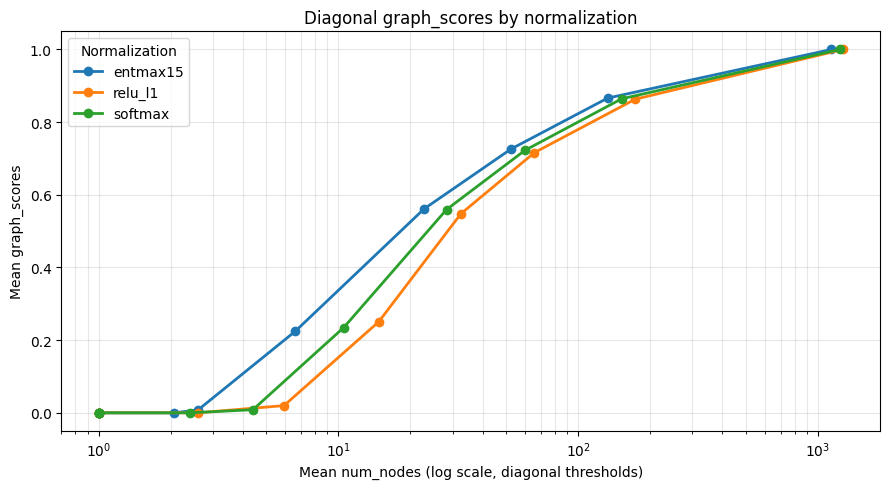

,normalization,node_inf,graph_score,num_nodes
0,entmax15,0.0,0.0,1.000000
1,entmax15,0.1,0.0,1.000000
2,entmax15,0.2,0.0,1.000000
3,entmax15,0.3,0.0,1.000000
4,entmax15,0.4,0.0,2.066667


In [10]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


def load_prune_scores_with_normalization(
    root_dir: str = "demos/eval_shap_prune/clt-hp",
    file_glob: str = "*_prune_graph.pt",
):
    """
    Expected layout:
      root_dir/<normalization>/node_inf_{x}_rel_{y}/*_prune_graph.pt
    """
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"Directory not found: {root}")

    threshold_dir_pattern = re.compile(
        r"^node_inf_(?P<node_inf>[-+]?\d*\.?\d+)_rel_(?P<node_rel>[-+]?\d*\.?\d+)$"
    )

    records = []
    for p in root.rglob(file_glob):
        threshold_dir = p.parent
        m = threshold_dir_pattern.match(threshold_dir.name)
        if not m:
            continue

        normalization = threshold_dir.parent.name
        node_inf = float(m.group("node_inf"))
        node_rel = float(m.group("node_rel"))

        payload = torch.load(p, map_location="cpu")
        if isinstance(payload, dict):
            score = payload.get("graph_scores", None)
            kept_ids = payload.get("kept_ids", None)
            pruned_adj = payload.get("pruned_adj", None)
        else:
            score = getattr(payload, "graph_scores", None)
            kept_ids = getattr(payload, "kept_ids", None)
            pruned_adj = getattr(payload, "pruned_adj", None)

        if score is None:
            continue
        score = float(score)
        if not np.isfinite(score):
            continue

        # Prefer explicit kept_ids length; fall back to pruned adjacency shape.
        if isinstance(kept_ids, list):
            num_nodes = int(len(kept_ids))
        elif hasattr(pruned_adj, "shape") and len(pruned_adj.shape) >= 1:
            num_nodes = int(pruned_adj.shape[0])
        else:
            num_nodes = np.nan

        records.append(
            {
                "normalization": normalization,
                "node_inf": node_inf,
                "node_rel": node_rel,
                "num_nodes": num_nodes,
                "graph_score": score,
                "file": str(p),
            }
        )

    if not records:
        raise RuntimeError(f"No matching prune graph files found under: {root}")

    return pd.DataFrame(records)


def plot_diagonal_by_normalization(df_scores: pd.DataFrame, tol: float = 1e-9):
    diag = df_scores[np.isclose(df_scores["node_inf"], df_scores["node_rel"], atol=tol)].copy()
    if diag.empty:
        raise RuntimeError("No diagonal points found (node_inf ~= node_rel).")

    # Aggregate across files at each diagonal threshold, then plot versus mean number of nodes.
    diag_mean = (
        diag.groupby(["normalization", "node_inf"], as_index=False)
        .agg(
            graph_score=("graph_score", "mean"),
            num_nodes=("num_nodes", "mean"),
        )
        .sort_values(["normalization", "num_nodes", "node_inf"])
    )

    plt.figure(figsize=(9, 5))
    for norm in sorted(diag_mean["normalization"].unique()):
        sub = diag_mean[diag_mean["normalization"] == norm]
        sub = sub[sub["num_nodes"] > 0]
        if sub.empty:
            continue
        plt.plot(
            sub["num_nodes"],
            sub["graph_score"],
            marker="o",
            linewidth=2,
            label=norm,
        )

    plt.xscale("log")
    plt.xlabel("Mean num_nodes (log scale, diagonal thresholds)")
    plt.ylabel("Mean graph_scores")
    plt.title("Diagonal graph_scores by normalization")
    plt.grid(True, alpha=0.3, which="both")
    plt.legend(title="Normalization")
    plt.tight_layout()
    plt.show()

    return diag_mean


def plot_heatmaps_by_normalization(df_scores: pd.DataFrame, normalizations: list[str] | None = None):
    norms = (
        normalizations
        if normalizations is not None
        else sorted(df_scores["normalization"].unique().tolist())
    )
    if not norms:
        raise RuntimeError("No normalization values available.")

    n = len(norms)
    fig, axes = plt.subplots(1, n, figsize=(5.2 * n, 4.8), squeeze=False)
    axes = axes[0]

    vmin = df_scores["graph_score"].min()
    vmax = df_scores["graph_score"].max()
    mappable = None

    for i, norm in enumerate(norms):
        ax = axes[i]
        sub = df_scores[df_scores["normalization"] == norm]

        if sub.empty:
            ax.set_title(f"{norm} (no data)")
            ax.axis("off")
            continue

        grid = (
            sub.groupby(["node_inf", "node_rel"], as_index=False)["graph_score"]
            .mean()
            .pivot(index="node_inf", columns="node_rel", values="graph_score")
            .sort_index(axis=0)
            .sort_index(axis=1)
        )

        im = ax.imshow(
            grid.values,
            aspect="auto",
            origin="lower",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
        )
        mappable = im

        ax.set_xticks(np.arange(len(grid.columns)))
        ax.set_xticklabels([f"{x:.1f}" for x in grid.columns], rotation=45, ha="right")
        ax.set_yticks(np.arange(len(grid.index)))
        ax.set_yticklabels([f"{x:.1f}" for x in grid.index])

        ax.set_xlabel("node_relevance_threshold")
        if i == 0:
            ax.set_ylabel("node_influence_threshold")
        ax.set_title(norm)

    if mappable is not None:
        fig.colorbar(mappable, ax=axes.tolist(), label="Mean graph_scores", shrink=0.9)

    fig.suptitle("Mean graph_scores heatmaps by normalization", y=1.02)
    fig.tight_layout()
    plt.show()


# Run
df_norm = load_prune_scores_with_normalization("eval_shap_prune/clt-hp")
diag_by_norm = plot_diagonal_by_normalization(df_norm)
# plot_heatmaps_by_normalization(df_norm, ["softmax", "relu_l1", "entmax15"])

diag_by_norm.head()